In [18]:
import librosa
import matplotlib.pyplot as plt
import librosa.display
import os
import numpy as np
from tensorflow.keras import layers
from IPython.display import Audio
import wave
import pandas as pd
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("../data_processing/sep28k-mfcc.csv")

In [20]:
df = df[df['NaturalPause'] == 0]
df = df[df['Block'] == 0]
df = df[df['Prolongation'] == 0]
df = df[df['WordRep'] == 0]
df = df[df['SoundRep'] == 0]
df.head()

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,...,29,30,31,32,33,34,35,36,37,38
2,HeStutters,0,2,34809760,34857760,0,0,0,0,0,...,-3.249218,-3.218731,0.360520,-0.115838,1.723229,-1.460772,-1.430723,-1.429669,-0.178196,-3.046811
4,HeStutters,0,4,35721920,35769920,0,0,0,0,0,...,-2.057481,-3.225782,-1.561315,-3.723942,-2.249673,-3.513439,-2.097951,-1.940040,0.020210,-0.556461
6,HeStutters,0,6,37251200,37299200,0,0,0,0,0,...,-4.985494,-6.181957,-2.396787,-6.544606,-2.319257,-3.688410,-0.221778,-1.690031,0.664374,-0.303436
9,HeStutters,0,9,41417440,41465440,0,0,0,0,0,...,-4.798577,-6.274436,-4.889234,-5.795599,-4.400376,-4.176473,-0.957432,-3.210292,0.577023,1.042720
10,HeStutters,0,10,41861760,41909760,0,0,0,0,0,...,-2.898894,-6.209611,-3.659979,-5.923317,-2.773856,-3.547750,2.452112,1.432807,3.639793,2.238830


In [21]:
df = df.reset_index()
df.head()

,index,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,...,29,30,31,32,33,34,35,36,37,38
0,2,HeStutters,0,2,34809760,34857760,0,0,0,0,...,-3.249218,-3.218731,0.360520,-0.115838,1.723229,-1.460772,-1.430723,-1.429669,-0.178196,-3.046811
1,4,HeStutters,0,4,35721920,35769920,0,0,0,0,...,-2.057481,-3.225782,-1.561315,-3.723942,-2.249673,-3.513439,-2.097951,-1.940040,0.020210,-0.556461
2,6,HeStutters,0,6,37251200,37299200,0,0,0,0,...,-4.985494,-6.181957,-2.396787,-6.544606,-2.319257,-3.688410,-0.221778,-1.690031,0.664374,-0.303436
3,9,HeStutters,0,9,41417440,41465440,0,0,0,0,...,-4.798577,-6.274436,-4.889234,-5.795599,-4.400376,-4.176473,-0.957432,-3.210292,0.577023,1.042720
4,10,HeStutters,0,10,41861760,41909760,0,0,0,0,...,-2.898894,-6.209611,-3.659979,-5.923317,-2.773856,-3.547750,2.452112,1.432807,3.639793,2.238830


In [22]:
df = df.drop(columns=['index'])
df.head()

,Show,EpId,ClipId,Start,Stop,Unsure,PoorAudioQuality,Prolongation,Block,SoundRep,...,29,30,31,32,33,34,35,36,37,38
0,HeStutters,0,2,34809760,34857760,0,0,0,0,0,...,-3.249218,-3.218731,0.360520,-0.115838,1.723229,-1.460772,-1.430723,-1.429669,-0.178196,-3.046811
1,HeStutters,0,4,35721920,35769920,0,0,0,0,0,...,-2.057481,-3.225782,-1.561315,-3.723942,-2.249673,-3.513439,-2.097951,-1.940040,0.020210,-0.556461
2,HeStutters,0,6,37251200,37299200,0,0,0,0,0,...,-4.985494,-6.181957,-2.396787,-6.544606,-2.319257,-3.688410,-0.221778,-1.690031,0.664374,-0.303436
3,HeStutters,0,9,41417440,41465440,0,0,0,0,0,...,-4.798577,-6.274436,-4.889234,-5.795599,-4.400376,-4.176473,-0.957432,-3.210292,0.577023,1.042720
4,HeStutters,0,10,41861760,41909760,0,0,0,0,0,...,-2.898894,-6.209611,-3.659979,-5.923317,-2.773856,-3.547750,2.452112,1.432807,3.639793,2.238830


In [23]:
df.to_csv("interjection.csv",index=False)

In [24]:
import os

def list_files(directory):
    return [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]

# Replace 'directory_path' with the path to your directory
directory_path = '/home/alien/Git/DATA/mel_spects_interjection'
# names_list = list_files(directory_path)
names_list = pd.read_csv("interjection.csv")['Name'].values.tolist()
# full_names_list = ["/home/alien/Git/DATA/mfcc_images/" + img + ".jpg" for img in names_list]
full_names_list = []
for img in names_list:
    corresponding_sound = df.loc[df['Name'] == img, 'Interjection'].values[0]
    if corresponding_sound == 0:
        full_names_list.append("/home/alien/Git/DATA/mel_spects_interjection/" + img + "_fluent.jpg")
    if corresponding_sound >= 1:
        full_names_list.append("/home/alien/Git/DATA/mel_spects_interjection/" + img + "_stutter.jpg")

print(full_names_list[-2])

/home/alien/Git/DATA/mel_spects_interjection/WomenWhoStutter_109_35_stutter.jpg


In [25]:
def load_all(imagefile_list):
    data = []
    labels = []

    for imagefile in imagefile_list:
        print(imagefile)
        image = cv2.imread(imagefile)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (224, 224))
        data.append(image)

        if "fluent" in imagefile:
            labels.append(0)
        else:
            labels.append(1)

    labels = np.array(labels)
    data = np.array(data)

    return data, labels

In [26]:
X, y = load_all(full_names_list)

/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_2_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_4_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_6_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_9_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_10_stutter.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_11_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_12_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_15_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_16_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_20_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_22_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_24_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_26_fluent.jpg
/home/alien/Git/DATA/mel_spects_interjection/HeStutters_0_29_fluent

In [27]:
print(X[0])
print(y[0])

[[[ 68  33  60]
  [ 96  28  68]
  [ 89  27  67]
  ...
  [  0   0   4]
  [  0   0   4]
  [  0   0   2]]

 [[114  57  88]
  [166  57 117]
  [157  55 112]
  ...
  [  0   0   4]
  [  0   0   4]
  [  0   0   2]]

 [[140  60  94]
  [190  55 118]
  [198  65 126]
  ...
  [  0   0   4]
  [  0   0   4]
  [  0   0   2]]

 ...

 [[126  65 103]
  [194  56 123]
  [189  69 128]
  ...
  [ 29  13  72]
  [ 18   5  59]
  [ 21   6  57]]

 [[ 90  48 102]
  [145  31 116]
  [141  39 122]
  ...
  [ 26  18  68]
  [ 24  17  63]
  [ 27  19  61]]

 [[ 86  33  88]
  [122  36 120]
  [134  36 131]
  ...
  [ 23  14  63]
  [ 27  18  70]
  [ 26  14  66]]]
0


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.3, random_state=12)

In [29]:
print("x_train shape:", X_train.shape)
print("x_test shape:", X_test.shape)
print('y_train shape:', y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (1693, 224, 224, 3)
x_test shape: (726, 224, 224, 3)
y_train shape: (1693,)
y_test shape: (726,)


In [30]:
print(len(X_train), len(X_test), len(y_train), len(y_test))

1693 726 1693 726


In [31]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_test))

Counter({0: 1189, 1: 504})
Counter({0: 509, 1: 217})


In [32]:
print(X_train)

[[[[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [ 93  35  71]
   [ 66  25  76]
   [ 68  24  71]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [178  70 113]
   [139  42 106]
   [130  46 108]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [220  82 117]
   [188  57 116]
   [173  57 121]]

  ...

  [[ 30  10  63]
   [ 36   7  81]
   [ 43   9  91]
   ...
   [103  30 134]
   [ 81  16 124]
   [ 77  19 122]]

  [[ 48  18  81]
   [ 59  21 105]
   [ 61  20 111]
   ...
   [103  28 131]
   [ 82  15 124]
   [ 76  19 121]]

  [[ 49  16  78]
   [ 63  19 109]
   [ 66  16 121]
   ...
   [ 98  29 127]
   [ 78  17 118]
   [ 75  19 118]]]


 [[[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [  0   0   4]
   [  0   0   4]
   [  0   0   2]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [  0   0   2]
   [  0   0   2]
   [  0   0   2]]

  [[  0   0   2]
   [  0   0   2]
   [  0   0   2]
   ...
   [  0   0   0]
   [  0   0   0]
   [  0   0

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import accuracy_score
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, MultiHeadAttention
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dropout, Flatten, Dense, Input, AveragePooling2D, Attention, Reshape, TimeDistributed, Bidirectional, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input, decode_predictions
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
vgg_model = tf.keras.models.load_model('./model_interjection_AUGMENT.keras')

I0000 00:00:1730689162.062286    3453 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1730689162.157727    3453 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1730689162.162463    3453 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1730689162.168987    3453 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [38]:
vgg_model.summary

<bound method Model.summary of <Functional name=functional, built=True>>

In [39]:
# Combine features
X_combined = np.concatenate((X_train, X_test), axis=0)

# Combine labels
y_combined = np.concatenate((y_train, y_test), axis=0)
# predictions
vgg_pred = vgg_model.predict(X_combined, batch_size=1)

vgg_pred = np.round(vgg_pred)

  # model evaluation
confusion = confusion_matrix(y_combined, vgg_pred)
print(classification_report(y_combined, vgg_pred))
print(confusion)

2024-11-03 21:59:26.744320: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
W0000 00:00:1730689166.859765    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689166.875712    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689166.879602    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689166.880026    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689166.881723    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689166.883340    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689166.884892    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689166.885337    4158 gpu_t

  23/2419 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step     

W0000 00:00:1730689167.148082    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.148582    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.149058    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.149530    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.150003    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.150485    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.150958    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.151438    4158 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1730689167.151922    4158 gp

2419/2419 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1698
           1       0.97      0.95      0.96       721

    accuracy                           0.98      2419
   macro avg       0.97      0.97      0.97      2419
weighted avg       0.98      0.98      0.98      2419

[[1676   22]
 [  33  688]]


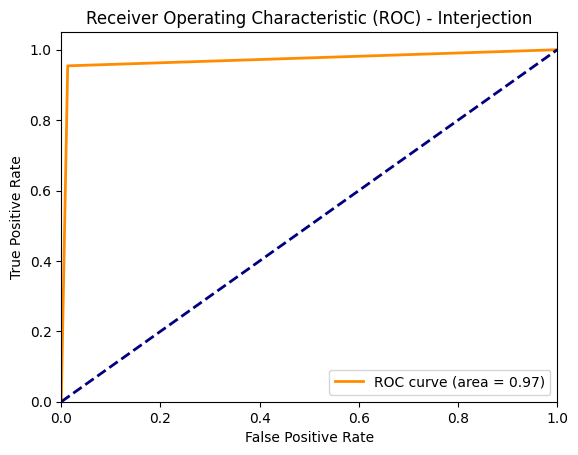

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming vgg_pred contains probabilities of belonging to class 1
fpr, tpr, thresholds = roc_curve(y_combined, vgg_pred)

# Calculate the area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Interjection')
plt.legend(loc="lower right")
plt.show()